# 연도별 출생 인구비교분석
- 국가통계포털 https://kosis.kr
- 월.분기.연간 인구동향(출생,사망,혼인,이혼)
- 행정구역별 전국제외/종류 출생아수/ 년도 1996 ~ 2025 선택
- 행렬 전환 선택

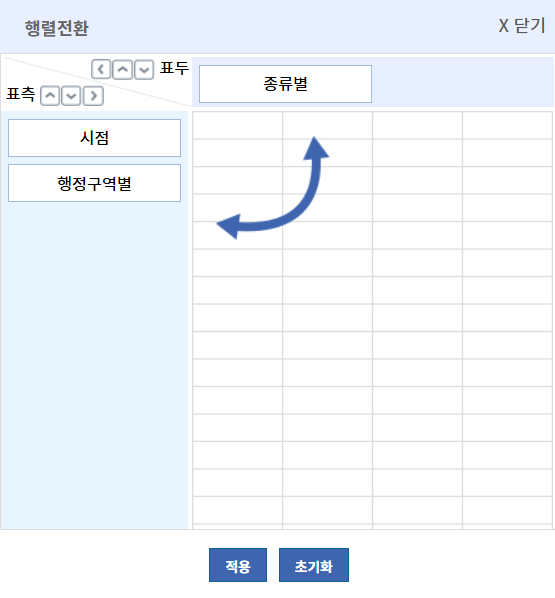

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Text(0.2, 0.4, '한글')

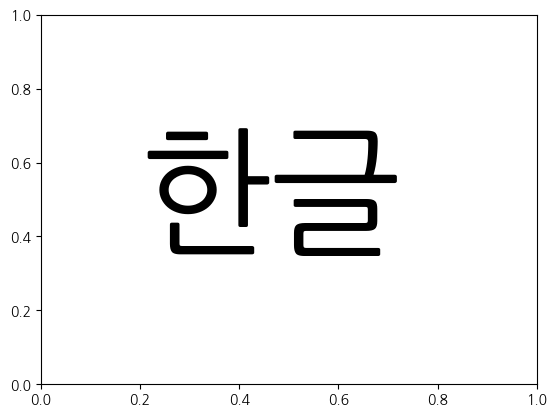

In [6]:
from hdfs import InsecureClient
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2, 0.4, '한글', size=100)

In [7]:
!pwd

/home/jovyan


In [11]:
# hdfs 업로드 실습
hdfs = InsecureClient('http://namenode:9870',user='hadoop')
# 파일 업로드 (Create)
print("\n[3] 파일 업로드")
local_file = '/home/jovyan/work/dataset/월분기연간인구동향출생202606.csv'
hdfs_file = '/dataset/hdfs월분기연간인구동향출생202606.csv'
hdfs.upload(hdfs_file, local_file, overwrite=True)
print(f"  업로드 완료: {hdfs_file}")



[3] 파일 업로드
  업로드 완료: /dataset/hdfs월분기연간인구동향출생202606.csv


In [12]:
hdfs_file = '/dataset/hdfs월분기연간인구동향출생202606.csv'

with hdfs.read(hdfs_file, encoding='EUC-KR') as reader:
    population = pd.read_csv(reader)
population.head()

,시점,행정구역별(1),출생아수(명)
0,2026.01 p),서울특별시,4961
1,2026.01 p),부산광역시,1467
2,2026.01 p),대구광역시,1117
3,2026.01 p),인천광역시,1726
4,2026.01 p),광주광역시,704


In [13]:
population.columns = ['year', 'location', 'data']
population['data'] = population['data'].str.replace('-','0').astype(int)
population['year'] = population['year'].str.replace(' p)','').astype(str)
population.head()

,year,location,data
0,2026.01,서울특별시,4961
1,2026.01,부산광역시,1467
2,2026.01,대구광역시,1117
3,2026.01,인천광역시,1726
4,2026.01,광주광역시,704


In [14]:
data1 = population.groupby(['location','year'], as_index=True)['data'].sum().reset_index()
data1

,location,year,data
0,강원특별자치도,1996,19432
1,강원특별자치도,1997,19821
2,강원특별자치도,1998,19421
3,강원특별자치도,1999,19143
4,강원특별자치도,2000,19482
...,...,...,...
556,충청북도,2024,7540
557,충청북도,2025,8240
558,충청북도,2026.01,905
559,충청북도,2026.02,751


In [16]:
# 백분율로 전환하기
# 각 지역별로 'data'열의 값을 합산 후, 백분율로 계산
data1['percent'] = data1.groupby('location')['data'].apply( lambda x : 100 * x / x.sum()).reset_index( drop=True)    
data1

,location,year,data,percent
0,강원특별자치도,1996,19432,5.240377
1,강원특별자치도,1997,19821,5.345282
2,강원특별자치도,1998,19421,5.237411
3,강원특별자치도,1999,19143,5.162440
4,강원특별자치도,2000,19482,5.253861
...,...,...,...,...
556,충청북도,2024,7540,1.831346
557,충청북도,2025,8240,2.001365
558,충청북도,2026.01,905,0.219810
559,충청북도,2026.02,751,0.182406


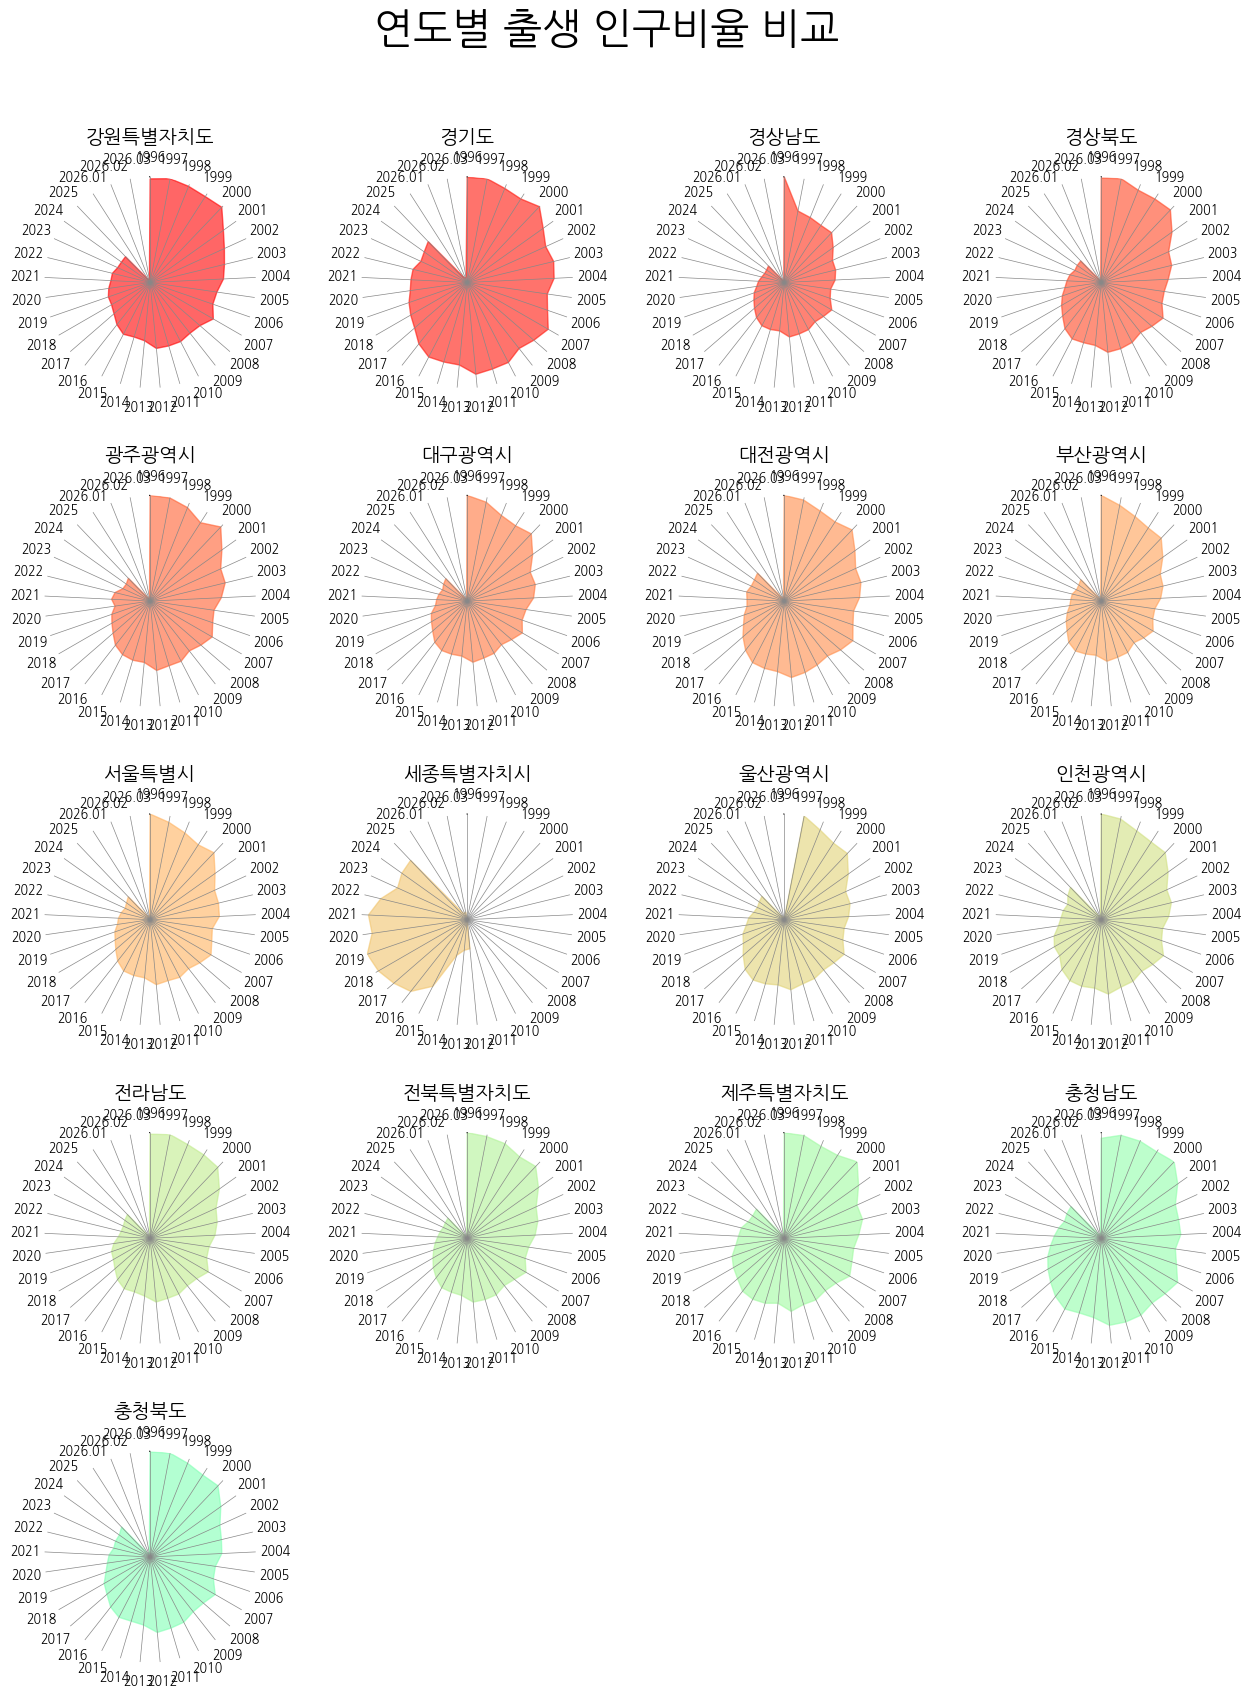

In [18]:
import numpy as np

pi = 3.141592
fig, axe = plt.subplots(5, 4 , figsize=(15,20), subplot_kw = dict(polar=True))

#서브플롯을 1차원 배열 형태로 변환
axs = axe.flat

# 고유한 년도 리스트 생성
year_list = list(data1['year'].unique())
# print(year_list)

# 지역별로 색상 설정
colors = [plt.cm.rainbow(a) for a in np.linspace(1.0 ,0.0 , len(year_list))]

# 서브플록 인덱스 초기화
i = 0

for location, data in data1.groupby('location'):
    # print(location, value)
    # 각 지역의 값 리스트 생성
    val = list(data['percent'])
    ex1_plot_data = val.copy()
    ex1_plot_data += ex1_plot_data[:1] # 마지막값을 처음값으로 넣기
    # 각 값에 대한 각도 계산
    angles = [n / float(len(val)) * 2 * pi for n in range(len(val))]
    angles += angles[:1] # 마지막값을 처음값으로 넣기 즉, 값 닫기

    # 서브플롯 설정
    axs[i].set_theta_offset(pi/2)  # 0도를 위쪽으로 설정
    axs[i].set_theta_direction(-1)  # 시계 반대 방향으로 각도 증가
    axs[i].set_rlabel_position(20)  # 반지름 레이블 위치 설정
    axs[i].xaxis.grid(True, color="#888888", linestyle='solid', linewidth=0.5)  # x축 그리드 설정
    axs[i].yaxis.grid(True, color="#888888", linestyle='solid', linewidth=0.5)  # y축 그리드 설정
    axs[i].set_rgrids([10, 20, 30, 40, 50, 60, 70, 80, 90, 100], fontsize=10)  # 반지름 그리드 설정
    axs[i].set_xticks(angles[:-1])  # x축 틱 설정
    axs[i].xaxis.set_ticklabels(list(year_list), fontsize=9)  # x축 틱 레이블 설정
    axs[i].set_ylim(0, max(val))  # y축 범위 설정

    # 선 그리기
    axs[i].plot(angles, ex1_plot_data, linewidth=0, linestyle='solid', zorder=3)

    # 배경 채우기
    axs[i].fill(angles, ex1_plot_data, color=colors[i], alpha=0.6)

    # 서브플롯 제목 설정
    axs[i].set_title(location, fontsize=14, position=(0.5, 1.1))    
    i += 1

# 데이터 없는 서브플롯 숨기기
for j in range(i, len(axs)):
    fig.delaxes(axs[j])

# 전체 플롯 제목을 설정
fig.suptitle("연도별 출생 인구비율 비교",fontsize=30, y=0.95)
# 서브플롯 간의 간격 조정
fig.subplots_adjust(wspace=0.5)
# 플롯을 그림파일로 저장
plt.savefig('연도별출생인구비율.png')
plt.show()

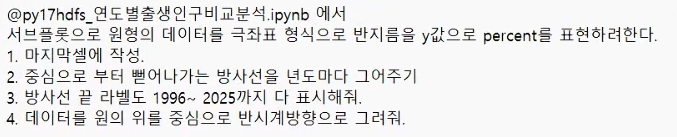

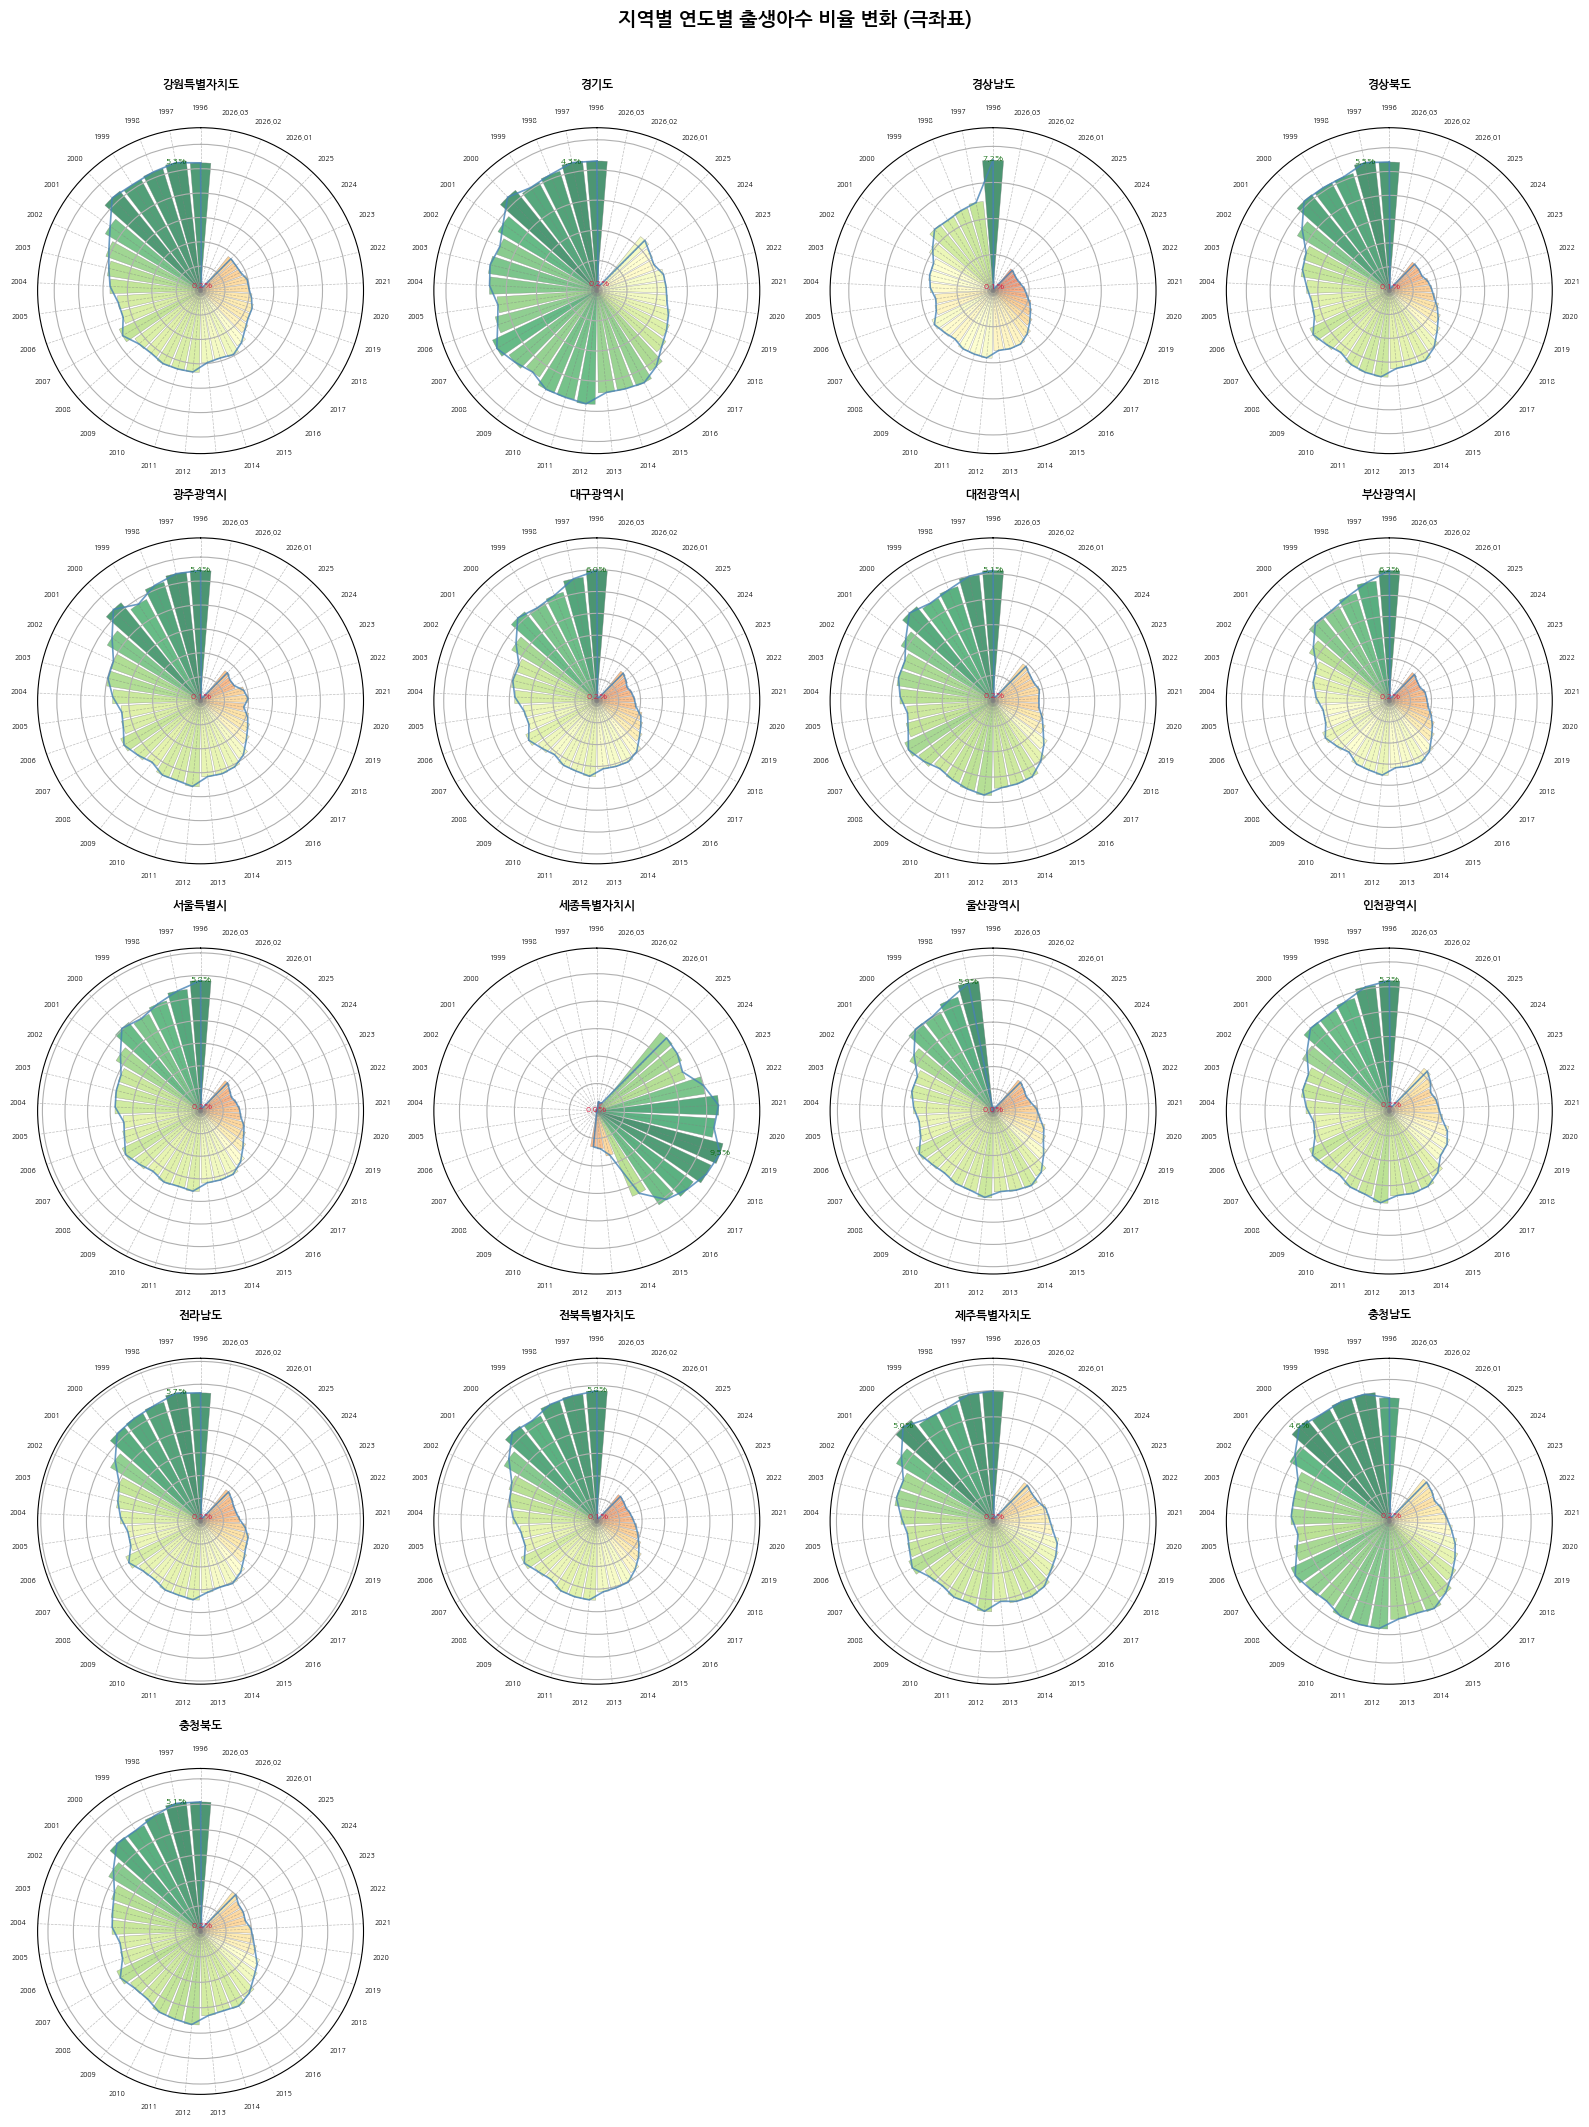

In [19]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

locations = data1['location'].unique()
n = len(locations)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4.2),
                         subplot_kw={'projection': 'polar'})
axes = axes.flatten()

for i, loc in enumerate(locations):
    ax = axes[i]

    # 위(N)를 0으로, 반시계방향
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(1)

    sub = data1[data1['location'] == loc].sort_values('year')

    years   = sub['year'].values
    percent = sub['percent'].values

    n_years = len(years)
    theta = np.linspace(0, 2 * np.pi, n_years, endpoint=False)

    theta_closed = np.append(theta, theta[0])
    r_closed     = np.append(percent, percent[0])

    colors = cm.RdYlGn(percent / percent.max())

    bar_width = 2 * np.pi / n_years * 0.85
    ax.bar(theta, percent, width=bar_width, color=colors,
           alpha=0.7, linewidth=0.3, edgecolor='gray')

    ax.plot(theta_closed, r_closed, color='steelblue', linewidth=1.2, alpha=0.8)

    ax.set_xticks(theta)
    ax.set_xticklabels([str(y) for y in years], fontsize=5)
    ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    ax.set_yticklabels([])
    ax.set_ylim(0, percent.max() * 1.25)

    max_idx = np.argmax(percent)
    min_idx = np.argmin(percent)
    ax.annotate(f"{percent[max_idx]:.1f}%",
                xy=(theta[max_idx], percent[max_idx]),
                fontsize=6, color='darkgreen', ha='center')
    ax.annotate(f"{percent[min_idx]:.1f}%",
                xy=(theta[min_idx], percent[min_idx]),
                fontsize=6, color='crimson', ha='center')

    ax.set_title(loc, fontsize=8.5, pad=12, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('지역별 연도별 출생아수 비율 변화 (극좌표)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()